In [ ]:
!pip install biopython

import pandas as pd
import time
from datetime import datetime
from Bio import Entrez

# Configure Entrez email (NCBI requirement)
Entrez.email = "your_email@example.com"  # TODO: Replace with your actual email

# Function to respect NCBI rate limits (max 3 requests per second without API key)
def respect_rate_limit():
    """Pauses execution to maintain < 3 requests per second."""
    time.sleep(0.34)  # 1/3 of a second + a small buffer

# Set the time horizon variables
start_date = "2000/01/01"
end_date = "2025/12/31"

print("Setup complete.")
print(f"Entrez email: {Entrez.email}")
print(f"Time Horizon: {start_date} to {end_date}")

Setup complete.
Entrez email: your_email@example.com
Time Horizon: 2000/01/01 to 2025/12/31


In [ ]:
# Base clause to ensure general neurology relevance
base_neurology_filter = '("Nervous System Diseases"[MeSH Terms] OR "Neurology"[Journal])'

# Publication type filter to include substantive research and exclude noise
pub_type_filter = 'AND ("Clinical Trial, Phase III"[pt] OR "Journal Article"[pt]) NOT ("Editorial"[pt] OR "Comment"[pt] OR "Letter"[pt] OR "News"[pt])'

# Dictionary of 10 neurology subspecialties with MeSH terms and Title/Abstract keywords
subspecialty_queries = {
    "Vascular/Stroke": f'(("Stroke"[MeSH Terms] OR "Cerebrovascular Disorders"[MeSH Terms] OR "stroke"[tiab] OR "cerebrovascular"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Epilepsy": f'(("Epilepsy"[MeSH Terms] OR "Seizures"[MeSH Terms] OR "epilepsy"[tiab] OR "seizure"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Movement Disorders": f'(("Movement Disorders"[MeSH Terms] OR "Parkinson Disease"[MeSH Terms] OR "movement disorder*"[tiab] OR "parkinson*"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Neuroimmunology/MS": f'(("Multiple Sclerosis"[MeSH Terms] OR "Demyelinating Diseases"[MeSH Terms] OR "multiple sclerosis"[tiab] OR "neuroimmunology"[tiab] OR "demyelinat*"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Neuromuscular": f'(("Neuromuscular Diseases"[MeSH Terms] OR "Peripheral Nervous System Diseases"[MeSH Terms] OR "neuromuscular"[tiab] OR "peripheral neuropathy"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Neurocritical Care": f'(("Intensive Care, Neurological"[MeSH Terms] OR "neurocritical care"[tiab] OR "neurointensive"[tiab] OR "neurotrauma"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Neuro-oncology": f'(("Central Nervous System Neoplasms"[MeSH Terms] OR "Brain Neoplasms"[MeSH Terms] OR "neuro-oncology"[tiab] OR "neurooncology"[tiab] OR "brain tumor*"[tiab] OR "glioma*"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Cognitive/Behavioral": f'(("Cognitive Dysfunction"[MeSH Terms] OR "Dementia"[MeSH Terms] OR "Alzheimer Disease"[MeSH Terms] OR "dementia"[tiab] OR "cognitive impairment"[tiab] OR "alzheimer*"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Headache": f'(("Headache Disorders"[MeSH Terms] OR "Migraine Disorders"[MeSH Terms] OR "headache*"[tiab] OR "migraine*"[tiab])) AND {base_neurology_filter} {pub_type_filter}',

    "Sleep Medicine": f'(("Sleep Wake Disorders"[MeSH Terms] OR "Sleep Apnea Syndromes"[MeSH Terms] OR "sleep disorder*"[tiab] OR "narcolepsy"[tiab] OR "sleep apnea"[tiab])) AND {base_neurology_filter} {pub_type_filter}'
}

# Print to verify
for subspecialty, query in list(subspecialty_queries.items())[:2]:
    print(f"--- {subspecialty} ---")
    print(f"{query}\n")
print(f"... and {len(subspecialty_queries)-2} more subspecialties configured.")

--- Vascular/Stroke ---
(("Stroke"[MeSH Terms] OR "Cerebrovascular Disorders"[MeSH Terms] OR "stroke"[tiab] OR "cerebrovascular"[tiab])) AND ("Nervous System Diseases"[MeSH Terms] OR "Neurology"[Journal]) AND ("Clinical Trial, Phase III"[pt] OR "Journal Article"[pt]) NOT ("Editorial"[pt] OR "Comment"[pt] OR "Letter"[pt] OR "News"[pt])

--- Epilepsy ---
(("Epilepsy"[MeSH Terms] OR "Seizures"[MeSH Terms] OR "epilepsy"[tiab] OR "seizure"[tiab])) AND ("Nervous System Diseases"[MeSH Terms] OR "Neurology"[Journal]) AND ("Clinical Trial, Phase III"[pt] OR "Journal Article"[pt]) NOT ("Editorial"[pt] OR "Comment"[pt] OR "Letter"[pt] OR "News"[pt])

... and 8 more subspecialties configured.


In [6]:
import urllib.error

years = list(range(2000, 2026))
results = {year: {} for year in years}

print("Starting PubMed data collection...")

for subspecialty, query in subspecialty_queries.items():
    print(f"Querying data for {subspecialty}...")
    for year in years:
        try:
            # Use mindate and maxdate parameters to filter by year
            handle = Entrez.esearch(
                db="pubmed",
                term=query,
                mindate=f"{year}/01/01",
                maxdate=f"{year}/12/31",
                datetype="pdat",
                retmax=0  # We only need the count, not the document IDs
            )
            record = Entrez.read(handle)
            handle.close()

            count = int(record["Count"])
            results[year][subspecialty] = count

            # Respect the 3 requests per second limit
            respect_rate_limit()

        except urllib.error.URLError as e:
            print(f"Network error querying {subspecialty} in {year}: {e}")
            results[year][subspecialty] = None
        except Exception as e:
            print(f"An error occurred querying {subspecialty} in {year}: {e}")
            results[year][subspecialty] = None

print("\nData collection complete!")


Starting PubMed data collection...
Querying data for Vascular/Stroke...
Querying data for Epilepsy...
Querying data for Movement Disorders...
Querying data for Neuroimmunology/MS...
Querying data for Neuromuscular...
Querying data for Neurocritical Care...
Querying data for Neuro-oncology...
Querying data for Cognitive/Behavioral...
Querying data for Headache...
Querying data for Sleep Medicine...

Data collection complete!


In [7]:
# Convert the dictionary of results to a Pandas DataFrame
df_counts = pd.DataFrame.from_dict(results, orient='index')
df_counts.index.name = 'Year'

# Display the top rows of the DataFrame
display(df_counts.head())

# Export the DataFrame to a CSV file
csv_filename = "neurology_publication_counts_2000_2025.csv"
df_counts.to_csv(csv_filename)
print(f"\nData successfully exported to {csv_filename}")


,Vascular/Stroke,Epilepsy,Movement Disorders,Neuroimmunology/MS,Neuromuscular,Neurocritical Care,Neuro-oncology,Cognitive/Behavioral,Headache,Sleep Medicine
Year,,,,,,,,,,
2000,7030,3463,2820,2063,5438,69,3357,3950,1223,1484
2001,7171,3293,2821,2091,5571,52,3457,4038,1364,1492
2002,7450,3459,3086,2086,5616,45,3325,4446,1353,1585
2003,8212,3520,3473,2294,5570,30,3691,4619,1521,1891
2004,9044,3677,3534,2350,6019,56,3796,5210,1633,2240



Data successfully exported to neurology_publication_counts_2000_2025.csv


In [8]:
# Calculate the grand total of all publications across all 10 subspecialties
total_publications = df_counts.sum().sum()

# Calculate the cumulative sum of publications for each individual subspecialty
subspecialty_totals = df_counts.sum()

# Identify which subspecialty has the absolute highest cumulative sum
largest_subspecialty = subspecialty_totals.idxmax()
largest_volume = subspecialty_totals.max()

# Print the findings clearly
print(f"Total abstract publications across all 10 subspecialties (2000-2025): {total_publications:,}")
print(f"Subspecialty with the largest publication volume: {largest_subspecialty} ({largest_volume:,} publications)")


Total abstract publications across all 10 subspecialties (2000-2025): 1,619,540
Subspecialty with the largest publication volume: Vascular/Stroke (379,976 publications)


In [9]:
start_year = 2000

# Determine if 2025 is artificially low compared to 2024
if df_counts.loc[2025].sum() >= df_counts.loc[2024].sum():
    end_year = 2025
else:
    end_year = 2024

num_years = end_year - start_year

# Calculate CAGR: (End Value / Start Value)^(1 / Years) - 1
cagrs = (df_counts.loc[end_year] / df_counts.loc[start_year]) ** (1 / num_years) - 1
cagrs_pct = cagrs * 100

# Sort the fields by CAGR in descending order
cagrs_sorted = cagrs_pct.sort_values(ascending=False)

# Identify the variables for greatest relative growth
highest_growth_field = cagrs_sorted.index[0]
highest_growth_rate = cagrs_sorted.iloc[0]

# Print the findings
print(f"Endpoint year used for CAGR calculation: {end_year}")
print(f"[greatest relative growth]: {highest_growth_field}")
print(f"[X]%: {highest_growth_rate:.2f}%\n")

print("Ranked list of subspecialties by CAGR (2000 to endpoint):")
for rank, (field, rate) in enumerate(cagrs_sorted.items(), 1):
    print(f"{rank}. {field}: {rate:.2f}%")


Endpoint year used for CAGR calculation: 2025
[greatest relative growth]: Neurocritical Care
[X]%: 6.64%

Ranked list of subspecialties by CAGR (2000 to endpoint):
1. Neurocritical Care: 6.64%
2. Sleep Medicine: 6.63%
3. Cognitive/Behavioral: 6.49%
4. Movement Disorders: 4.79%
5. Vascular/Stroke: 4.29%
6. Neuro-oncology: 4.14%
7. Headache: 4.08%
8. Neuroimmunology/MS: 3.90%
9. Neuromuscular: 3.15%
10. Epilepsy: 2.81%


In [10]:
# Calculate total publications for the start and end years across all 10 fields
total_2000 = df_counts.loc[start_year].sum()
total_end = df_counts.loc[end_year].sum()

# Calculate percentage share for each field in both years
share_2000 = (df_counts.loc[start_year] / total_2000) * 100
share_end = (df_counts.loc[end_year] / total_end) * 100

# Calculate the change in share
share_change = share_end - share_2000

# Identify fields that increased and decreased
fields_increased = share_change[share_change > 0].index.tolist()
fields_decreased = share_change[share_change < 0].index.tolist()

# Print the findings clearly for the variables
print(f"Comparing relative share from {start_year} to {end_year}:\n")

print("[fields increased]:")
for field in fields_increased:
    print(f" - {field} (from {share_2000[field]:.2f}% to {share_end[field]:.2f}%, change: +{share_change[field]:.2f}%)")

print("\n[fields decreased]:")
for field in fields_decreased:
    print(f" - {field} (from {share_2000[field]:.2f}% to {share_end[field]:.2f}%, change: {share_change[field]:.2f}%)")


Comparing relative share from 2000 to 2025:

[fields increased]:
 - Movement Disorders (from 9.13% to 9.82%, change: +0.69%)
 - Neurocritical Care (from 0.22% to 0.37%, change: +0.15%)
 - Cognitive/Behavioral (from 12.78% to 20.54%, change: +7.75%)
 - Sleep Medicine (from 4.80% to 7.97%, change: +3.17%)

[fields decreased]:
 - Vascular/Stroke (from 22.75% to 21.70%, change: -1.05%)
 - Epilepsy (from 11.21% to 7.47%, change: -3.74%)
 - Neuroimmunology/MS (from 6.68% to 5.79%, change: -0.88%)
 - Neuromuscular (from 17.60% to 12.76%, change: -4.84%)
 - Neuro-oncology (from 10.87% to 9.99%, change: -0.87%)
 - Headache (from 3.96% to 3.59%, change: -0.37%)


In [11]:
# Calculate year-over-year (YoY) percentage change for total publications across all fields
total_yearly_counts = df_counts.sum(axis=1)
yoy_growth_total = total_yearly_counts.pct_change() * 100

# Identify the year with the maximum YoY growth (inflection point)
max_yoy_year = yoy_growth_total.idxmax()
max_yoy_rate = yoy_growth_total.max()

# Formulate the additional findings sentence
additional_findings = f"Notably, the overall publication volume experienced its most significant year-over-year spike in {int(max_yoy_year)}, with a {max_yoy_rate:.1f}% increase compared to the preceding year."

# Helper function to format lists cleanly for natural language
def format_list(items):
    if len(items) == 1:
        return items[0]
    elif len(items) == 2:
        return f"{items[0]} and {items[1]}"
    else:
        return ", ".join(items[:-1]) + f", and {items[-1]}"

fields_inc_str = format_list(fields_increased)
fields_dec_str = format_list(fields_decreased)

# Construct the final abstract paragraph using the exact template
final_abstract = (
    f"RESULTS We identified {total_publications:,} publications across 10 subspecialties. "
    f"From {start_year} to {end_year}, {highest_growth_field} demonstrated the greatest relative growth "
    f"({highest_growth_rate:.2f}%), whereas {largest_subspecialty} accounted for the largest publication volume. "
    f"The relative share of publications increased for {fields_inc_str} and decreased for {fields_dec_str}. "
    f"{additional_findings}"
)

print("Final Abstract 'RESULTS' Paragraph:\n")
print(final_abstract)


Final Abstract 'RESULTS' Paragraph:

RESULTS We identified 1,619,540 publications across 10 subspecialties. From 2000 to 2025, Neurocritical Care demonstrated the greatest relative growth (6.64%), whereas Vascular/Stroke accounted for the largest publication volume. The relative share of publications increased for Movement Disorders, Neurocritical Care, Cognitive/Behavioral, and Sleep Medicine and decreased for Vascular/Stroke, Epilepsy, Neuroimmunology/MS, Neuromuscular, Neuro-oncology, and Headache. Notably, the overall publication volume experienced its most significant year-over-year spike in 2020, with a 8.8% increase compared to the preceding year.


In [12]:
# Calculate absolute growth by subtracting start_year counts from end_year counts
absolute_growth = df_counts.loc[end_year] - df_counts.loc[start_year]

# Convert to DataFrame, name the column, and sort in descending order
df_absolute_growth = pd.DataFrame(absolute_growth, columns=['Absolute_Growth'])
df_absolute_growth = df_absolute_growth.sort_values(by='Absolute_Growth', ascending=False)

# Display the results
print(f"Absolute Publication Growth ({start_year} to {end_year}):\n")
display(df_absolute_growth)

Absolute Publication Growth (2000 to 2025):



,Absolute_Growth
Cognitive/Behavioral,15071
Vascular/Stroke,13066
Neuromuscular,6377
Movement Disorders,6272
Sleep Medicine,5902
Neuro-oncology,5896
Epilepsy,3454
Neuroimmunology/MS,3302
Headache,2103
Neurocritical Care,275


In [13]:
# Safely get start values, adding 1 if the value is 0 to prevent division by zero
start_values = df_counts.loc[start_year].apply(lambda x: x if x > 0 else x + 1)
end_values = df_counts.loc[end_year]
num_years = end_year - start_year

# Calculate CAGR: (End / Start)^(1 / Years) - 1
cagr_safe = (end_values / start_values) ** (1 / num_years) - 1
cagr_safe_pct = cagr_safe * 100

# Convert to DataFrame, sort from highest to lowest, and round to 2 decimal places
df_cagr = pd.DataFrame(cagr_safe_pct, columns=['CAGR (%)'])
df_cagr = df_cagr.sort_values(by='CAGR (%)', ascending=False).round(2)

# Display the results
print(f"Compound Annual Growth Rate (CAGR) from {start_year} to {end_year}:\n")
display(df_cagr)

Compound Annual Growth Rate (CAGR) from 2000 to 2025:



,CAGR (%)
Neurocritical Care,6.64
Sleep Medicine,6.63
Cognitive/Behavioral,6.49
Movement Disorders,4.79
Vascular/Stroke,4.29
Neuro-oncology,4.14
Headache,4.08
Neuroimmunology/MS,3.90
Neuromuscular,3.15
Epilepsy,2.81


In [14]:
# Calculate percentage shares for start and end years
share_start = (df_counts.loc[start_year] / df_counts.loc[start_year].sum()) * 100
share_end = (df_counts.loc[end_year] / df_counts.loc[end_year].sum()) * 100

# Compute the net shift in percentage points
net_shift = share_end - share_start

# Consolidate into a formatted DataFrame
df_shares = pd.DataFrame({
    f'{start_year} Share (%)': share_start,
    f'{end_year} Share (%)': share_end,
    'Net Shift (% pts)': net_shift
})

# Sort by Net Shift descending to highlight gains vs losses
df_shares = df_shares.sort_values(by='Net Shift (% pts)', ascending=False).round(2)

# Display the table
print(f"Relative Publication Share Shift ({start_year} to {end_year}):\n")
display(df_shares)

Relative Publication Share Shift (2000 to 2025):



,2000 Share (%),2025 Share (%),Net Shift (% pts)
Cognitive/Behavioral,12.78,20.54,7.75
Sleep Medicine,4.80,7.97,3.17
Movement Disorders,9.13,9.82,0.69
Neurocritical Care,0.22,0.37,0.15
Headache,3.96,3.59,-0.37
Neuro-oncology,10.87,9.99,-0.87
Neuroimmunology/MS,6.68,5.79,-0.88
Vascular/Stroke,22.75,21.70,-1.05
Epilepsy,11.21,7.47,-3.74
Neuromuscular,17.60,12.76,-4.84


In [15]:
!pip install pwlf

In [16]:
import pwlf
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.multitest as smt

# Prepare the DataFrame for modeling
df_modeling = df_counts.copy()

# Reset index to make 'Year' a standard column and ensure it's an integer
df_modeling = df_modeling.reset_index()
df_modeling['Year'] = df_modeling['Year'].astype(int)

# Create 'Total_Neurology' background offset column (sum of all fields per year)
df_modeling['Total_Neurology'] = df_counts.sum(axis=1).values

# Verify formatting
print("Modeling DataFrame Setup Complete:")
display(df_modeling.head())

Modeling DataFrame Setup Complete:


,Year,Vascular/Stroke,Epilepsy,Movement Disorders,Neuroimmunology/MS,Neuromuscular,Neurocritical Care,Neuro-oncology,Cognitive/Behavioral,Headache,Sleep Medicine,Total_Neurology
0,2000,7030,3463,2820,2063,5438,69,3357,3950,1223,1484,30897
1,2001,7171,3293,2821,2091,5571,52,3457,4038,1364,1492,31350
2,2002,7450,3459,3086,2086,5616,45,3325,4446,1353,1585,32451
3,2003,8212,3520,3473,2294,5570,30,3691,4619,1521,1891,34821
4,2004,9044,3677,3534,2350,6019,56,3796,5210,1633,2240,37559


Analyzing the top 3 fastest-growing fields: Neurocritical Care, Sleep Medicine, Cognitive/Behavioral



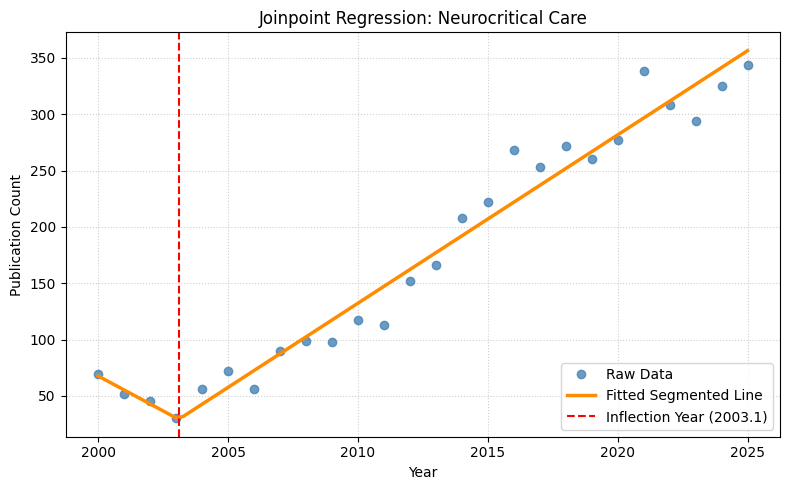

► Neurocritical Care: Inflection point detected at year 2003.10



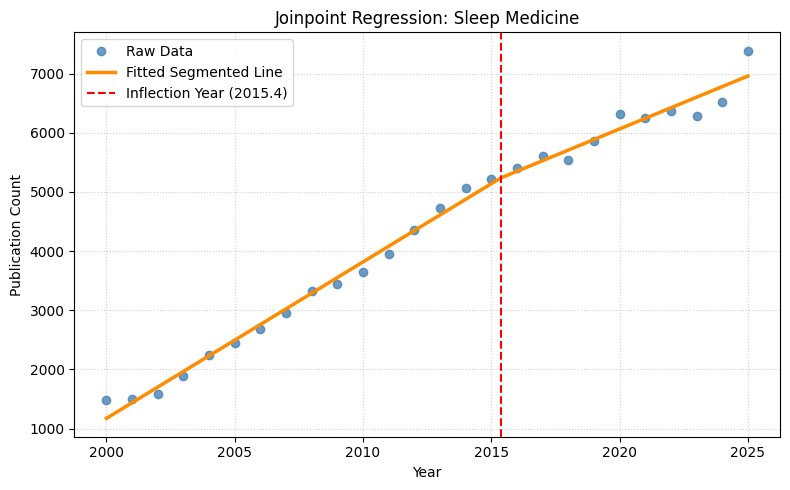

► Sleep Medicine: Inflection point detected at year 2015.36



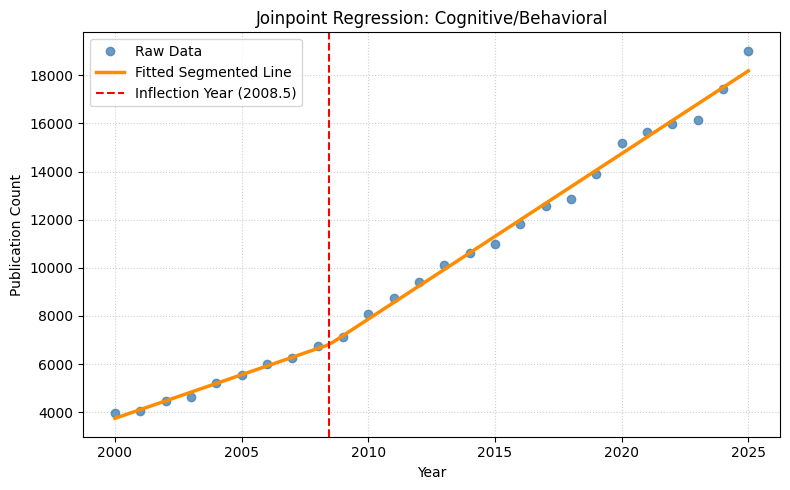

► Cognitive/Behavioral: Inflection point detected at year 2008.47



In [17]:
import matplotlib.pyplot as plt
import numpy as np

def find_and_plot_joinpoint(field, df, min_year, max_year):
    x = df['Year'].values
    y = df[field].values

    # Initialize the piecewise linear fit object
    my_pwlf = pwlf.PiecewiseLinFit(x, y)

    # Fit with 1 joinpoint (which means 2 segments).
    # We provide bounds as a list of tuples to restrict the search space for the single breakpoint.
    breaks = my_pwlf.fit(2, bounds=[(min_year, max_year)])

    # Generate a dense range of x-values to plot a smooth fitted line
    x_hat = np.linspace(x.min(), x.max(), 100)
    y_hat = my_pwlf.predict(x_hat)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(x, y, 'o', color='steelblue', label='Raw Data', alpha=0.8)
    plt.plot(x_hat, y_hat, '-', color='darkorange', linewidth=2.5, label='Fitted Segmented Line')

    # The 'breaks' array returns [min_x, joinpoint, max_x]. We want the middle value.
    inflection_year = breaks[1]
    plt.axvline(x=inflection_year, color='red', linestyle='--', label=f'Inflection Year ({inflection_year:.1f})')

    plt.title(f'Joinpoint Regression: {field}')
    plt.xlabel('Year')
    plt.ylabel('Publication Count')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    print(f"► {field}: Inflection point detected at year {inflection_year:.2f}\n")

# Identify the top 3 fastest-growing subspecialties from the df_cagr DataFrame
top_3_fields = df_cagr.head(3).index.tolist()
print(f"Analyzing the top 3 fastest-growing fields: {', '.join(top_3_fields)}\n")

# Run the joinpoint regression function for each of the top 3 fields
for field in top_3_fields:
    find_and_plot_joinpoint(field, df_modeling, 2003, 2022)

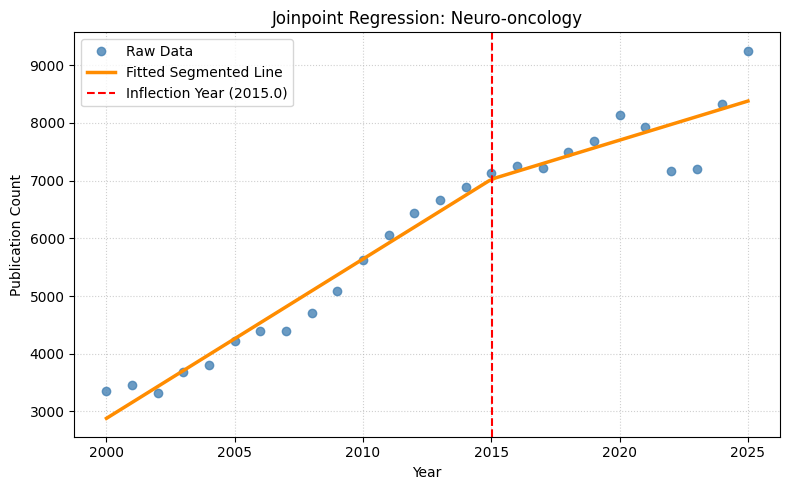

► Neuro-oncology: Inflection point detected at year 2015.02



In [18]:
# Run the joinpoint regression analysis specifically for Neuro-oncology
find_and_plot_joinpoint('Neuro-oncology', df_modeling, 2003, 2022)

In [20]:
import numpy as np
import statsmodels.formula.api as smf
import warnings

# Suppress optimization warnings for cleaner output
warnings.filterwarnings('ignore', module='statsmodels')

# Calculate the offset: natural log of Total_Neurology
offset_val = np.log(df_modeling['Total_Neurology'])

# Center the 'Year' variable to prevent exponential overflow during optimization (starts at 0)
df_modeling['Year_Centered'] = df_modeling['Year'] - df_modeling['Year'].min()

p_values_results = []
significant_growers = []

print("Negative Binomial Regression Results (Year Coefficient):\n")

# Iterate through each of the 10 subspecialties
for field in subspecialty_queries.keys():
    # Use the centered year to ensure convergence
    formula = f"Q('{field}') ~ Year_Centered"

    model = smf.negativebinomial(formula=formula, data=df_modeling, offset=offset_val)

    try:
        # Fit the model using bfgs for more robust optimization
        result = model.fit(disp=0, method='bfgs')

        # Extract the coefficient and p-value for 'Year_Centered'
        year_coef = result.params['Year_Centered']
        year_pval = result.pvalues['Year_Centered']

        p_values_results.append({
            'Subspecialty': field,
            'Coefficient': year_coef,
            'P-value': year_pval
        })

        # Determine if growth was significantly faster than baseline
        if year_coef > 0 and year_pval < 0.05:
            sig_status = "Significant"
            significant_growers.append(field)
        else:
            sig_status = "Not Significant"

        print(f"{field:<25} | Coef: {year_coef:>7.4f} | p-value: {year_pval:>8.2e} | {sig_status}")
    except Exception as e:
        print(f"{field:<25} | Model Error: {e}")

print("\n" + "="*60)
print("SUMMARY: Subspecialties growing significantly faster than baseline neurology rate:\n")
for field in significant_growers:
    print(f" 📈 {field}")

Negative Binomial Regression Results (Year Coefficient):

Vascular/Stroke           | Coef: -0.0007 | p-value: 3.14e-01 | Not Significant
Epilepsy                  | Coef: -0.0144 | p-value: 3.08e-155 | Not Significant
Movement Disorders        | Coef:  0.0001 | p-value: 8.42e-01 | Not Significant
Neuroimmunology/MS        | Coef: -0.0018 | p-value: 7.57e-02 | Not Significant
Neuromuscular             | Coef: -0.0104 | p-value: 8.64e-81 | Not Significant
Neurocritical Care        | Coef:  0.0440 | p-value: 2.10e-25 | Significant
Neuro-oncology            | Coef: -0.0060 | p-value: 2.60e-08 | Not Significant
Cognitive/Behavioral      | Coef:  0.0179 | p-value: 1.37e-80 | Significant
Headache                  | Coef: -0.0075 | p-value: 1.22e-09 | Not Significant
Sleep Medicine            | Coef:  0.0165 | p-value: 8.10e-24 | Significant

SUMMARY: Subspecialties growing significantly faster than baseline neurology rate:

 📈 Neurocritical Care
 📈 Cognitive/Behavioral
 📈 Sleep Medicine


In [21]:
import pandas as pd
import statsmodels.stats.multitest as smt

# Extract subspecialty names and raw p-values from the previous results list
subspecialties = [item['Subspecialty'] for item in p_values_results]
raw_pvals = [item['P-value'] for item in p_values_results]

# Apply Benjamini-Hochberg FDR correction
# alpha=0.05 is the family-wise error rate we are targeting
reject, pvals_corrected, _, _ = smt.multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Construct a DataFrame for a clean, tabular display
df_fdr = pd.DataFrame({
    'Subspecialty': subspecialties,
    'Raw P-value': raw_pvals,
    'Adjusted P-value': pvals_corrected,
    'Significant (FDR < 0.05)': reject
})

# Format the p-values into scientific notation for cleaner viewing
df_fdr['Raw P-value'] = df_fdr['Raw P-value'].apply(lambda x: f"{x:.2e}")
df_fdr['Adjusted P-value'] = df_fdr['Adjusted P-value'].apply(lambda x: f"{x:.2e}")

print("Multiple Comparisons Correction (Benjamini-Hochberg FDR):\n")
display(df_fdr)

Multiple Comparisons Correction (Benjamini-Hochberg FDR):



,Subspecialty,Raw P-value,Adjusted P-value,Significant (FDR < 0.05)
0,Vascular/Stroke,3.14e-01,3.49e-01,False
1,Epilepsy,3.08e-155,3.08e-154,True
2,Movement Disorders,8.42e-01,8.42e-01,False
3,Neuroimmunology/MS,7.57e-02,9.46e-02,False
4,Neuromuscular,8.64e-81,4.32e-80,True
5,Neurocritical Care,2.10e-25,5.24e-25,True
6,Neuro-oncology,2.60e-08,3.72e-08,True
7,Cognitive/Behavioral,1.37e-80,4.58e-80,True
8,Headache,1.22e-09,2.03e-09,True
9,Sleep Medicine,8.10e-24,1.62e-23,True
